In [1]:
from google.colab import files
import io
import pandas as pd
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

Saving CC GENERAL (1).csv to CC GENERAL (1).csv


In [4]:
df.shape

(8950, 18)

In [5]:
df.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Task
Explore the `df` DataFrame by inspecting its structure, identifying data types, checking for missing values, and examining descriptive statistics for numerical columns.

## Explore Data

### Subtask:
Inspect the loaded credit card dataset (df) to understand its structure, identify data types, and check for missing values. This step will also involve examining descriptive statistics for numerical columns.


**Reasoning**:
To understand the structure of the dataframe, identify data types, check for missing values, and examine descriptive statistics, I will use the `.info()`, `.isnull().sum()`, and `.describe()` methods on the `df` DataFrame.



In [6]:
print("DataFrame Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int

## Handle Missing Values and Outliers

### Subtask:
Address any missing values in the dataset. Depending on the nature and extent of missingness, strategies like imputation (mean, median, mode) or removal of rows/columns will be applied. Also, identify and handle potential outliers if necessary for clustering.


**Reasoning**:
The subtask requires imputing missing values in the 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS' columns with their respective median values. Calculating and applying the median in place for both columns will address this requirement.



In [7]:
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


/tmp/ipython-input-1600303445.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
/tmp/ipython-input-1600303445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

**Reasoning**:
The previous code generated a `FutureWarning` due to the use of `inplace=True` with chained assignment. To fix this and ensure the imputation is applied correctly and without warnings, I will explicitly assign the result of the `fillna` operation back to the DataFrame columns.



In [8]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


## Feature Scaling

### Subtask:
Scale the numerical features to ensure that all variables contribute equally to the clustering process, preventing features with larger values from dominating the distance calculations. Techniques like StandardScaler or MinMaxScaler will be considered.


**Reasoning**:
I need to identify the numerical columns (excluding 'CUST_ID'), import StandardScaler, instantiate it, fit and transform the data, and then create a new DataFrame with the scaled data and original column names.



In [9]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale (excluding CUST_ID)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'CUST_ID' in numerical_cols:
    numerical_cols.remove('CUST_ID')

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
df_scaled_array = scaler.fit_transform(df[numerical_cols])

# Create a new DataFrame with scaled data
df_scaled = pd.DataFrame(df_scaled_array, columns=numerical_cols)

print("First 5 rows of the scaled DataFrame:")
print(df_scaled.head())
print("\nDescriptive statistics of the scaled DataFrame:")
print(df_scaled.describe())

First 5 rows of the scaled DataFrame:
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.678661                         -0.916995 

## Determine Optimal Clusters

### Subtask:
Apply methods such as the Elbow Method or Silhouette Score to determine the optimal number of clusters (k) for the K-Means algorithm. This step is crucial for effective segmentation.


**Reasoning**:
To determine the optimal number of clusters using the Elbow Method, I will iterate through a range of cluster numbers, fit a K-Means model for each, calculate the Within-Cluster Sum of Squares (WCSS), and then plot these values to find the 'elbow' point.



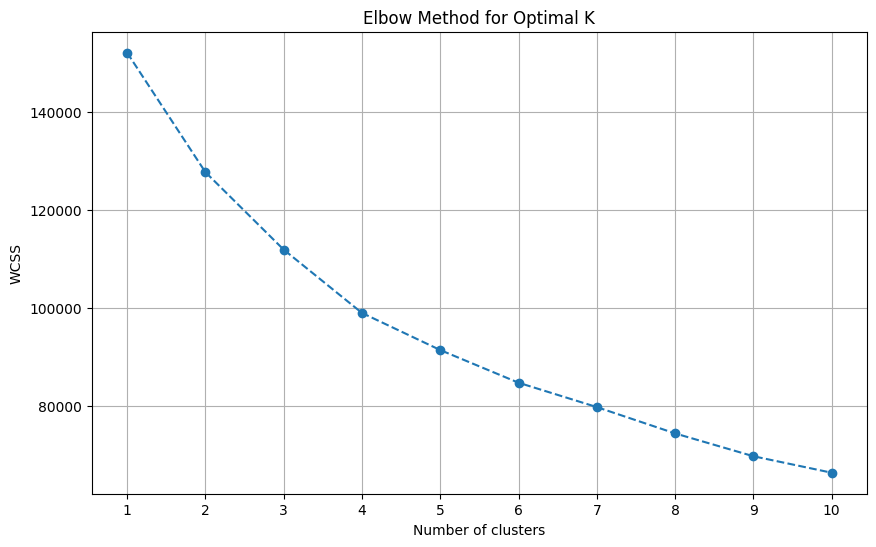

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11): # Looping for k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

The Elbow Method plot above helps in determining the optimal number of clusters. We look for the 'elbow' point in the graph, where the rate of decrease in WCSS (Within-Cluster Sum of Squares) significantly slows down. In this plot, the elbow appears to be around **k = 4** or **k = 5**. This suggests that adding more clusters beyond this point does not contribute much to the reduction of variance within clusters.

## Apply K-Means Clustering

### Subtask:
Perform K-Means clustering on the preprocessed data using the optimal number of clusters identified in the previous step. Assign each customer to a cluster.


**Reasoning**:
To perform K-Means clustering as instructed, I will instantiate the KMeans model with the specified parameters, fit it to the scaled data, and then assign the resulting cluster labels to both the scaled and original DataFrames.



In [11]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

df_scaled['Cluster'] = clusters
df['Cluster'] = clusters

print("First 5 rows of scaled DataFrame with clusters:")
print(df_scaled.head())
print("\nFirst 5 rows of original DataFrame with clusters:")
print(df.head())

First 5 rows of scaled DataFrame with clusters:
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.678661                         

## Analyze and Visualize Clusters

### Subtask:
Analyze the characteristics of each cluster by examining the mean or median values of the original features within each cluster. Visualize the clusters, perhaps using dimensionality reduction techniques like PCA for a 2D or 3D plot, and plot the cluster centers. Ensure to add a legend to the visualization for clarity.


**Reasoning**:
To analyze the characteristics of each cluster, I will calculate the mean of all features within each cluster using the original DataFrame and then display these mean values.



In [12]:
print("Mean of features per cluster:")
print(df.groupby('Cluster').mean())

Mean of features per cluster:


TypeError: agg function failed [how->mean,dtype->object]

**Reasoning**:
The previous code failed because the 'CUST_ID' column is of object type (string) and cannot be included in a mean calculation. To fix this, I will drop the 'CUST_ID' column before calculating the mean for each cluster. Then, I will proceed to apply PCA for dimensionality reduction and visualize the clusters as per the subtask instructions.



Mean of features per cluster:
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        1012.658327           0.789924   270.041785        209.937299   
1        3551.153761           0.986879  7681.620098       5095.878826   
2        4602.449658           0.968389   501.862982        320.188797   
3         894.907458           0.934734  1236.178934        593.974874   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                     60.371441    596.509903             0.170145   
1                   2587.208264    653.638891             0.946418   
2                    181.759123   4521.509581             0.287832   
3                    642.478274    210.570626             0.885165   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                        

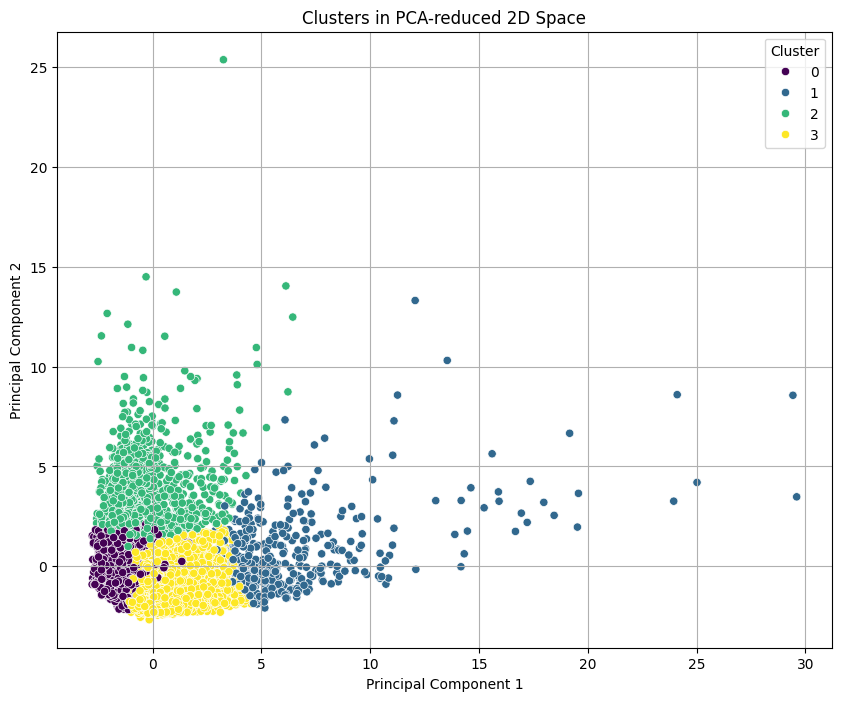

In [13]:
print("Mean of features per cluster:")
print(df.drop('CUST_ID', axis=1).groupby('Cluster').mean())

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Instantiate PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
df_pca_array = pca.fit_transform(df_scaled.drop('Cluster', axis=1))

# Create a new DataFrame with the PCA components
df_pca = pd.DataFrame(data=df_pca_array, columns=['PC1', 'PC2'])

# Add the 'Cluster' column to the PCA DataFrame
df_pca['Cluster'] = df_scaled['Cluster']

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', legend='full')
plt.title('Clusters in PCA-reduced 2D Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()